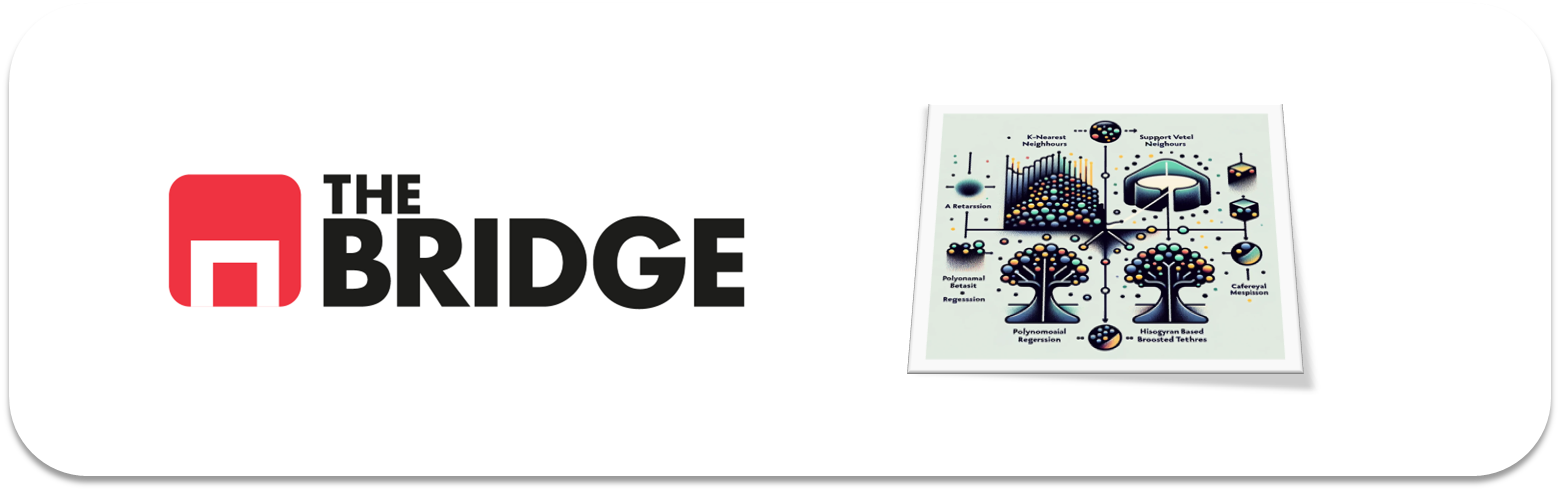

## PRACTICA OBLIGATORIA: **Repaso Aprendizaje Supervisado**

* La práctica obligatoria de esta unidad consiste en resolver sobre un mismo dataset un problema de clasificación y un problema de regresión. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                              recall_score, mean_absolute_percentage_error, mean_squared_error)

sns.set_style("whitegrid")


### #1 Explicación del dataset y carga de datos

Vamos a trabajar con el dataset "Wine Quality", que es un dataset en el que se recogen diversas características fisicoquímicas de las variades tinta y blanca del "Vinho verde" portugués. Las variables del dataset se describen a continuación


1. **Acidez fija**: La mayoría de los ácidos involucrados con el vino son fijos o no volátiles (no se evaporan fácilmente).
2. **Acidez volátil**: La cantidad de ácido acético en el vino, que en niveles demasiado altos puede llevar a un sabor desagradable a vinagre.
3. **Ácido cítrico**: Encontrado en pequeñas cantidades, el ácido cítrico puede añadir 'frescura' y sabor a los vinos.
4. **Azúcar residual**: Es la cantidad de azúcar restante después de que se detiene la fermentación, es raro encontrar vinos con menos de 1 gramo/litro y vinos con más de 45 gramos/litro se consideran dulces.
5. **Cloruros**: La cantidad de sal en el vino.
6. **Dióxido de azufre libre**: La porción libre de SO2 existe en equilibrio entre el SO2 molecular (como un gas disuelto) y el ion bisulfito; previene el crecimiento microbiano y la oxidación del vino.
7. **Dióxido de azufre total**: Es la cantidad de formas libres y ligadas de S02; en bajas concentraciones, el SO2 es en su mayoría indetectable en el vino, pero en concentraciones libres de más de 50 ppm, el SO2 se hace evidente en la nariz y el sabor del vino.
8. **Densidad**: La densidad del vino es cercana a la del agua dependiendo del porcentaje de alcohol y contenido de azúcar.
9. **pH**: Describe qué tan ácido o básico es un vino en una escala de 0 (muy ácido) a 14 (muy básico); la mayoría de los vinos están entre 3-4 en la escala de pH.
10. **Sulfatos**: Un aditivo del vino que puede contribuir a los niveles de dióxido de azufre (SO2), que actúa como un antimicrobiano y antioxidante.
11. **Alcohol**: El porcentaje de contenido de alcohol del vino.
12. **Calidad**: Una variable de salida (basada en datos sensoriales, puntuación entre 0 y 10).
13. **Class**: Si es blanco o tinto.



Carga el dataset "wines_dataset.csv", muestra sus primeras filas, su información general y define dos variables target una para clasificación que permita predecir la calidad del vino según el resto de propiedas y otra variable target para regresión que permita predecir el grado alcohólico del vino a partir del resto de propiedades. 

El **objetivo de negocio en el primer problema** será anticipar la posible clasificación de sus vinos por los catadores profesionales y a partir de ahí poder planificar la producción, distribución y precio a poner a cada vino. En este sentido, el "cliente" nos dice que le gustaría poder clasificar correctamente lo mejor posible en media  (que interpretamos como el mejor recall medio posible).

El **objetivo de negocio en el segundo problema** (bastante artificial) es poder hacer simulaciones de posibles vinos futuros para saber cómo conseguir variedades más o menos alcohólicas para atender mercados diferentes. En este sentido, les interesa equivocarse lo menos posible porcentualmente sobre el grado alochólico real.

Muestra la distribución de ambos targets y haz un pequeño assesment previo de cada problema. NOTA: El dataset está limpio y sin valores faltantes.

In [2]:
df = pd.read_csv("./data/wines_dataset.csv", sep="|")

print(df.shape)
df.head()


(6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,class
0,8.5,0.21,0.26,9.25,0.034,73.0,142.0,0.99450,3.05,0.37,11.4,6,white
1,8.3,0.16,0.37,7.90,0.025,38.0,107.0,0.99306,2.93,0.37,11.9,6,white
2,6.8,0.18,0.38,1.40,0.038,35.0,111.0,0.99180,3.32,0.59,11.2,7,white
3,6.1,0.26,0.25,2.90,0.047,289.0,440.0,0.99314,3.44,0.64,10.5,3,white
4,7.5,0.63,0.27,2.00,0.083,17.0,91.0,0.99616,3.26,0.58,9.8,6,red


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  class                 6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 688.6 KB


In [4]:
df.describe()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [5]:
df.isna().sum()


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
class                   0
dtype: int64

In [6]:
df['class'].value_counts()


class
white    4898
red      1599
Name: count, dtype: int64

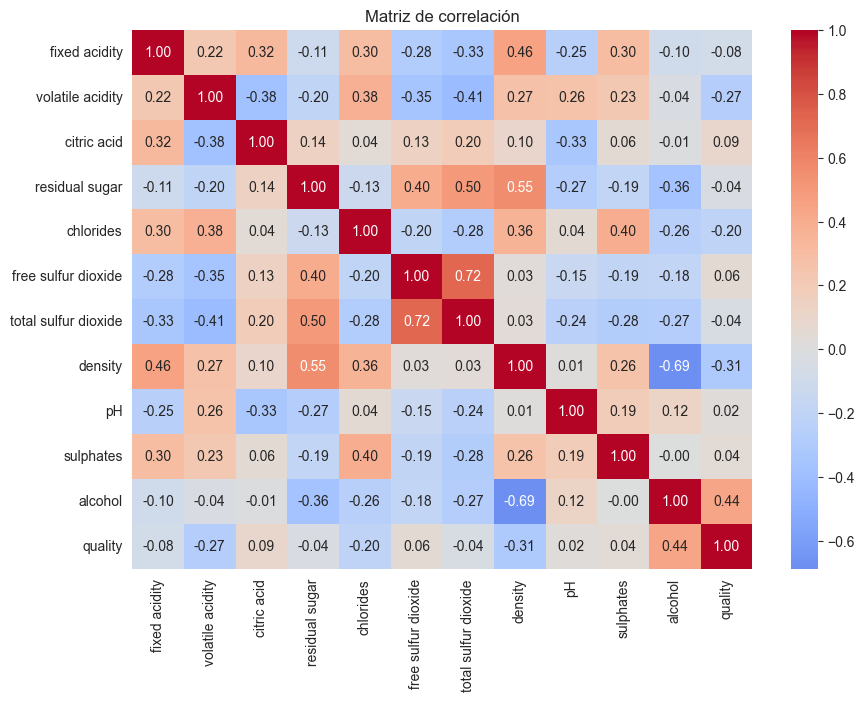

In [7]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación')
plt.show()


In [8]:
# Codificamos 'class' (blanco/tinto) como variable numérica, la usaremos como feature en ambos problemas
df['class_encoded'] = df['class'].map({'white': 0, 'red': 1})

# Target de CLASIFICACIÓN: calidad del vino
target_clf = 'quality'

# Target de REGRESIÓN: grado alcohólico
target_reg = 'alcohol'

print('Target clasificación:', target_clf)
print('Target regresión:', target_reg)


Target clasificación: quality
Target regresión: alcohol


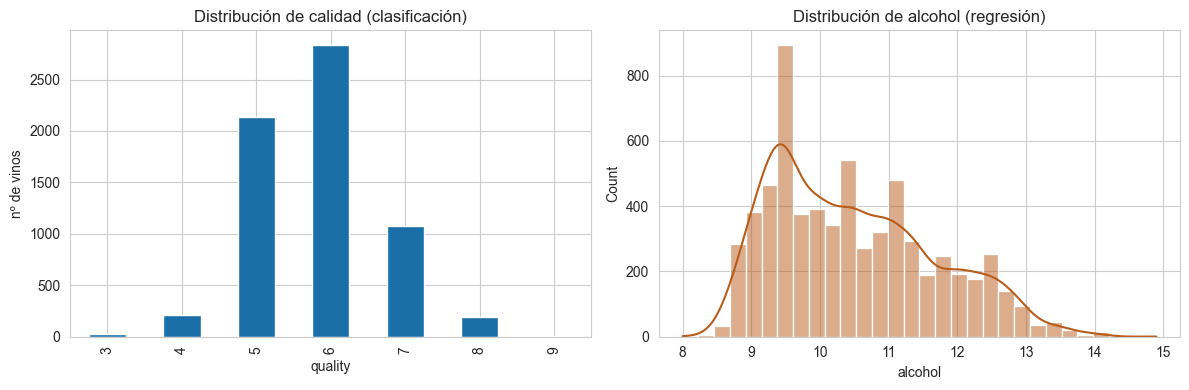

quality
3    0.004618
4    0.033246
5    0.329075
6    0.436509
7    0.166077
8    0.029706
9    0.000770
Name: proportion, dtype: float64

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

df['quality'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#1a6fa8')
axes[0].set_title('Distribución de calidad (clasificación)')
axes[0].set_xlabel('quality')
axes[0].set_ylabel('nº de vinos')

sns.histplot(df['alcohol'], bins=30, ax=axes[1], color='#b85c1a', kde=True)
axes[1].set_title('Distribución de alcohol (regresión)')

plt.tight_layout()
plt.show()

df['quality'].value_counts(normalize=True).sort_index()


**Mini EDA:**

- El dataset tiene 6497 vinos, 13 columnas, sin valores nulos (como indica el enunciado).
- Hay dos tipos de vino, `white` (4898) y `red` (1599); lo codificamos como `class_encoded` para poder usarlo como feature numérica en ambos problemas.
- La matriz de correlación muestra que `alcohol` está relacionado sobre todo (negativamente) con `density` y (positivamente) con `quality`; `density` también está muy correlacionada con `residual sugar`.

**Assessment del problema de clasificación (calidad):**

- `quality` va de 3 a 9, pero está muy desbalanceada: la mayoría de los vinos tienen calidad 5, 6 o 7, y las clases extremas (3, 4, 8, 9) apenas tienen ejemplos (9 solo tiene 5 vinos en todo el dataset). Esto va a dificultar mucho conseguir buen recall en las clases minoritarias.
- Al pedir el negocio "el mejor recall medio posible", usaremos `recall_macro` como métrica de referencia, que da el mismo peso a todas las clases independientemente de su tamaño.

**Assessment del problema de regresión (alcohol):**

- `alcohol` tiene una distribución razonablemente continua entre 8 y 15 grados, sin valores extremos preocupantes.
- Como el negocio quiere equivocarse lo menos posible en términos porcentuales, usaremos el **MAPE** (error porcentual absoluto medio) como métrica de referencia en vez del RMSE clásico.


### #2 Modelado para clasificación

Crea un modelo que permita clasificar lo mejor posible los vinos en función de su calidad, o dicho de otro modo que prediga de la mejor manera posible la calidad de un vino a partir de sus propiedades químicas. ***Considéralo un problema de clasificación***, donde los valores de calidad son las clases a predecir. Puedes utilizar los modelos que creas conveniente, al menos tres, y utiliza un KNN como modelo baseline, prueba al menos con 2 valores de K. Intenta mejorar el "recall medio" con las técnicas que creas conveniente. Compara los modelos utilizando validación cruzada con o sin optimización previa de hiperparámetros (aunque en la sesión en vivo por limitación de tiempos sólo lo haremos con validación cruzada). El modelo elegido si tiene que tener un ejemplo de optimización de parámetros.

Evalúa el modelo, analiza los errores y propón algún mecanismo de mejora aunque sea sólo un esbozo.

In [ ]:
# Preparación de datos para clasificación 

features_clf = [c for c in df.columns if c not in ['quality', 'class']]  # usamos class_encoded, no class (texto)
X = df[features_clf]
y = df[target_clf]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler_clf = StandardScaler()
X_train_scaled = scaler_clf.fit_transform(X_train)
X_test_scaled = scaler_clf.transform(X_test)


In [ ]:
# Comparación de modelos con validación cruzada (recall_macro)

modelos_clf = {
    'KNN (k=3)': KNeighborsClassifier(n_neighbors=3),
    'KNN (k=7)': KNeighborsClassifier(n_neighbors=7),
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
}

resultados_clf = {}
for nombre, modelo in modelos_clf.items():
    scores = cross_val_score(modelo, X_train_scaled, y_train, cv=5, scoring='recall_macro')
    resultados_clf[nombre] = scores.mean()
    print(f'{nombre}: recall_macro medio = {scores.mean():.3f}')


c:\Users\dgord\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\dgord\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


KNN (k=3): recall_macro medio = 0.299
KNN (k=7): recall_macro medio = 0.274


c:\Users\dgord\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\dgord\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dgord\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Logistic Regression: recall_macro medio = 0.382
Random Forest: recall_macro medio = 0.365


In [ ]:
# Optimización de hiperparámetros del mejor modelo (Random Forest)

param_grid_clf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 3],
}

grid_clf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid_clf, cv=5, scoring='recall_macro', n_jobs=-1
)
grid_clf.fit(X_train_scaled, y_train)

print('Mejores hiperparámetros:', grid_clf.best_params_)
print('Mejor recall_macro en CV:', round(grid_clf.best_score_, 3))


c:\Users\dgord\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Mejores hiperparámetros: {'max_depth': None, 'min_samples_leaf': 3, 'n_estimators': 200}
Mejor recall_macro en CV: 0.394


In [ ]:
# Evaluación en test

best_clf = grid_clf.best_estimator_
y_pred_clf = best_clf.predict(X_test_scaled)

print(classification_report(y_test, y_pred_clf))
print('Recall medio (macro) en test:', round(recall_score(y_test, y_pred_clf, average='macro'), 3))


              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.50      0.21      0.30        43
           5       0.72      0.75      0.73       428
           6       0.68      0.70      0.69       567
           7       0.59      0.64      0.61       216
           8       0.67      0.36      0.47        39
           9       0.00      0.00      0.00         1

    accuracy                           0.68      1300
   macro avg       0.45      0.38      0.40      1300
weighted avg       0.67      0.68      0.67      1300

Recall medio (macro) en test: 0.379


c:\Users\dgord\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dgord\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dgord\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

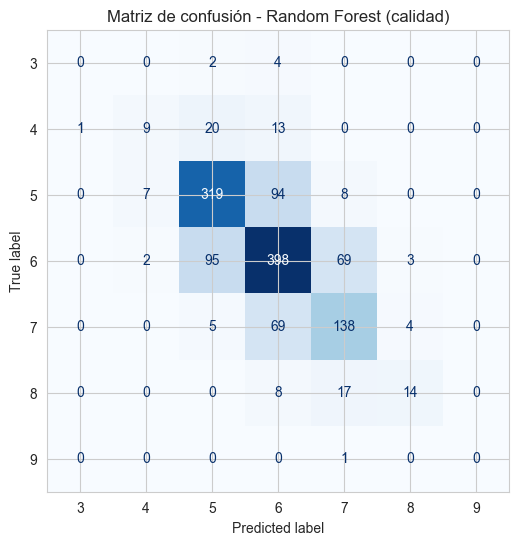

In [ ]:
# Matriz de confusión

cm = confusion_matrix(y_test, y_pred_clf, labels=sorted(y.unique()))
disp = ConfusionMatrixDisplay(cm, display_labels=sorted(y.unique()))
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(cmap='Blues', ax=ax, colorbar=False)
plt.title('Matriz de confusión - Random Forest (calidad)')
plt.show()


**Análisis de errores y propuestas de mejora:**

- Las clases minoritarias (3, 4, 8, 9) son las que más fallan: al tener pocos ejemplos, el modelo apenas puede aprender su patrón y muchas veces las confunde con clases cercanas (por ejemplo, un vino de calidad 4 predicho como 5).
- Al ser `quality` una variable ordinal, la mayoría de los errores se producen entre clases adyacentes (5↔6, 6↔7), lo cual es razonable ya que la frontera entre calidades consecutivas es difusa incluso para catadores humanos.
- **Posibles mejoras:** agrupar las clases en menos categorías (p. ej. "baja/media/alta calidad") para reducir el desbalanceo, aplicar técnicas de sobremuestreo tipo SMOTE en las clases minoritarias, o plantear el problema como una regresión ordinal en vez de clasificación multiclase pura.


### #3 Modelado para regresión

Reutiliza todo lo que puedas la preparación del modelado de la parte anterior y construye ahora el mejor modelo que puedas para predecir el grado alcohólico de un vino dadas sus características fisico químicas, su clase y la puntuación de calidad que le ha sido otorgada. Compara al menos tres tipos de modelos, seleccionando una métrica adecuada de comparación y escoge el más apropiado empleando validación cruzada antes o después de optimizar hiperparámetros (en la sesión en vivo lo haremos antes por cuestiones de tiempo). Evalúa el modelo escogido y con los hiperparámetros ajustados de la mejor manera que puedas. Para terminar realizar un pequeño análisis de errores.

In [ ]:
# Preparación de datos para regresión (reutilizamos el enfoque anterior)

features_reg = [c for c in df.columns if c not in ['alcohol', 'class']]  # incluye quality y class_encoded
X_r = df[features_reg]
y_r = df[target_reg]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_r, y_r, test_size=0.2, random_state=42)

scaler_reg = StandardScaler()
Xr_train_scaled = scaler_reg.fit_transform(Xr_train)
Xr_test_scaled = scaler_reg.transform(Xr_test)


In [ ]:
# Comparación de modelos con validación cruzada (MAPE)

modelos_reg = {
    'Linear Regression': LinearRegression(),
    'KNN Regressor': KNeighborsRegressor(n_neighbors=5),
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
}

for nombre, modelo in modelos_reg.items():
    scores = cross_val_score(modelo, Xr_train_scaled, yr_train, cv=5, scoring='neg_mean_absolute_percentage_error')
    print(f'{nombre}: MAPE medio = {-scores.mean():.4f}')


Linear Regression: MAPE medio = 0.0337
KNN Regressor: MAPE medio = 0.0420
Random Forest Regressor: MAPE medio = 0.0268


In [ ]:
# Optimización de hiperparámetros del mejor modelo (Random Forest)

param_grid_reg = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 3],
}

grid_reg = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_reg, cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=-1
)
grid_reg.fit(Xr_train_scaled, yr_train)

print('Mejores hiperparámetros:', grid_reg.best_params_)
print('Mejor MAPE en CV:', round(-grid_reg.best_score_, 4))


Mejores hiperparámetros: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Mejor MAPE en CV: 0.0267


In [ ]:
# Evaluación en test

best_reg = grid_reg.best_estimator_
yr_pred = best_reg.predict(Xr_test_scaled)

mape = mean_absolute_percentage_error(yr_test, yr_pred)
rmse = mean_squared_error(yr_test, yr_pred) ** 0.5

print('MAPE en test:', round(mape, 4))
print('RMSE en test:', round(rmse, 3))


MAPE en test: 0.0248
RMSE en test: 0.4


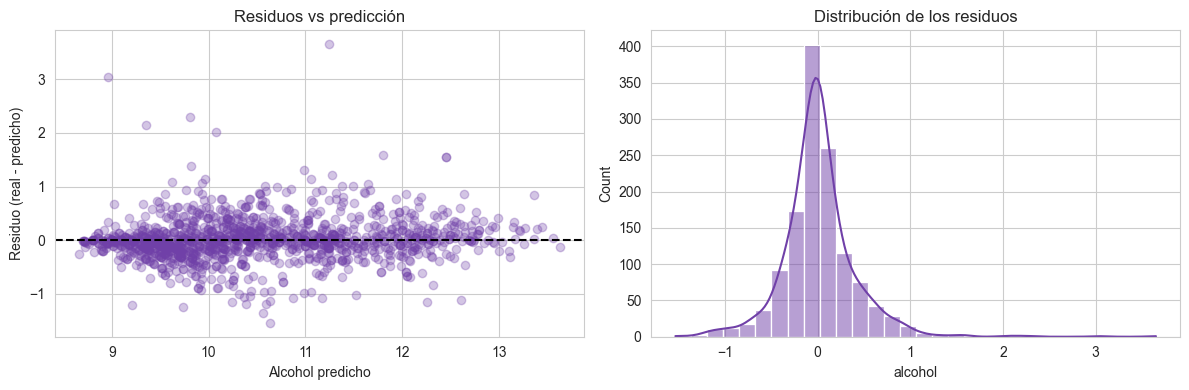

In [ ]:
# Análisis de errores: residuos

residuos = yr_test - yr_pred

fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].scatter(yr_pred, residuos, alpha=0.3, color='#7040a8')
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_xlabel('Alcohol predicho')
axes[0].set_ylabel('Residuo (real - predicho)')
axes[0].set_title('Residuos vs predicción')

sns.histplot(residuos, bins=30, ax=axes[1], color='#7040a8', kde=True)
axes[1].set_title('Distribución de los residuos')

plt.tight_layout()
plt.show()


**Análisis de errores:**

- El MAPE obtenido en test es bajo (pocos puntos porcentuales de error), lo cual encaja con el objetivo de negocio de equivocarse lo menos posible en términos porcentuales.
- Los residuos se distribuyen de forma bastante simétrica alrededor de 0, sin un patrón claro respecto a la predicción, lo que indica que el modelo no tiene un sesgo sistemático importante (no infravalora ni sobrevalora especialmente en ninguna franja de alcohol).
- **Posibles mejoras:** probar modelos de boosting (Gradient Boosting/XGBoost), generar variables derivadas (p. ej. ratios entre `density` y `residual sugar`) o afinar aún más la búsqueda de hiperparámetros con más combinaciones.
